In [ ]:
# 1. 각 wf 별로 시간순으로 계측, 진행 공정을 나열

In [1]:
# 각 계측값의 특성을 요약, 특성이란 계측값 별로 어떤한 공정이 진행되고 난후 계측된 것이지 맥락을 의미

In [5]:
#context란 이전 공정 또는 계측 기록을 압축
#context에는 project가 정의되어 있어 원하는 공정의 진행 횟수 등을 압축할 수 있다
#list_of_steps는 공정 이름과 진행 시간의 나열
#wf 객체에서 context는 모든 step별로 계산되면 각 context는 각 step 이전의 모든 step 정보를 포함
#project는 context를 압축하는 함수수


from dataclasses import dataclass
from datetime import datetime

#계측 기록
계측기록 = {'계측 코드' : {"계측 포인트" : "계측 결과"}}
#계측 코드 = 계측 STEP + 계측 PPID + 계측 시간 -> 즉 wf의 단일 step 항목의 concat

@dataclass  
class StepLog:
    step: str
    ppid: str
    time: str
    
    

wf = [(0,'step1','step1_ppid1'), (1, 'step2', 'step2_ppid2'), (2, 'step3', 'step3_ppid3')] # wf의 나열
context = [[],[(0,'step1','step1_ppid1')], [(0,'step1','step1_ppid1'), (1, 'step2', 'step2_ppid2')]]

#위의 로직을 generate_context 함수로 구현
def generate_context(wf):
    context = []
    for i in range(len(wf)):
        context.append(wf[:i])
    return context

generate_context(wf)








[[],
 [(0, 'step1', 'step1_ppid1')],
 [(0, 'step1', 'step1_ppid1'), (1, 'step2', 'step2_ppid2')]]

In [ ]:
class Measurement:
    #계측의 구성 요소. 1. 계측 시간, 2. 계측 레시피 이름, 3. 계측 결과 -> 계측 항목, 포인트 : 값을 딕셔너리로
    def __init__(self, time, recipe_name, result):
        self.time = time
        self.recipe_name = recipe_name
        self.result = result

#계측 결과의 계측 포인트를 특정한 규칙을 통해 일반화된 이름으로 변환
def point_to_name(point, lambda_function):
    return lambda_function(point)

#예시, 디시 계측 결과를 C,M,E,E2,E1으로 변환

def dishing_point_to_name(point):
    normal_points = ['C','M','E','E2','E1']
    #포인트는 S1,S2... 또는 그냥 1,2,3... 형식으로 주어짐
    #1. 계측 포인트가 5개 이상이면 맨 뒤부터 E1,E2,E,M,C 순으로 변환
    #2. 계측 포인트가 4개 이하이면 맨 뒤부터 E,M,C 순으로 변환
    point_numbers = [int(p) for p in point if p.isdigit()] #S01,S02,S03... 형식 변환 필요]
    if len(point_numbers) == 0:
        return point
    elif len(point_numbers) >= 5:
        return normal_points[len(point_numbers)-1]
    else:
        return normal_points[len(point_numbers)-1]









class Wafer(list):
    #진행된 계측과 공정들을 시간 순으로 나열한 Nx3 리스트
    def __init__(self, *args):
        super().__init__(*args)
        self.time_list = []
        self.process_list = []
        self.measurement_list = []
    def add_measurement(self, time, process, measurement):
        self.time_list.append(time)


In [6]:
import numpy as np

In [21]:
np.fft.fftfreq(100, 0.001)

array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
         90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,  170.,
        180.,  190.,  200.,  210.,  220.,  230.,  240.,  250.,  260.,
        270.,  280.,  290.,  300.,  310.,  320.,  330.,  340.,  350.,
        360.,  370.,  380.,  390.,  400.,  410.,  420.,  430.,  440.,
        450.,  460.,  470.,  480.,  490., -500., -490., -480., -470.,
       -460., -450., -440., -430., -420., -410., -400., -390., -380.,
       -370., -360., -350., -340., -330., -320., -310., -300., -290.,
       -280., -270., -260., -250., -240., -230., -220., -210., -200.,
       -190., -180., -170., -160., -150., -140., -130., -120., -110.,
       -100.,  -90.,  -80.,  -70.,  -60.,  -50.,  -40.,  -30.,  -20.,
        -10.])

In [27]:
np.fft.fftfreq(1000000, 1)

array([ 0.e+00,  1.e-06,  2.e-06, ..., -3.e-06, -2.e-06, -1.e-06])

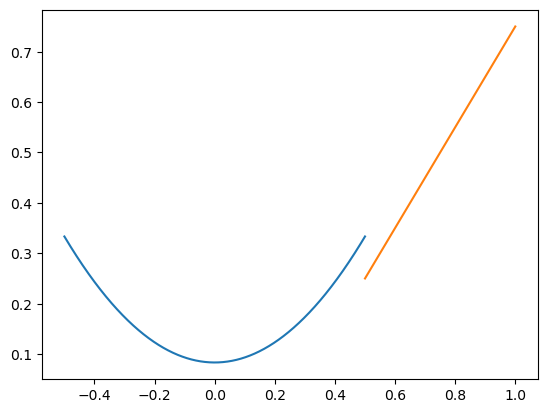

In [48]:
xs = np.linspace(-0.5,0.5,1000)
ys = (xs**2 + 1/12)
plt.plot(xs, ys)
xs = np.linspace(0.5,1,1000)
plt.plot(xs, xs-1/4)


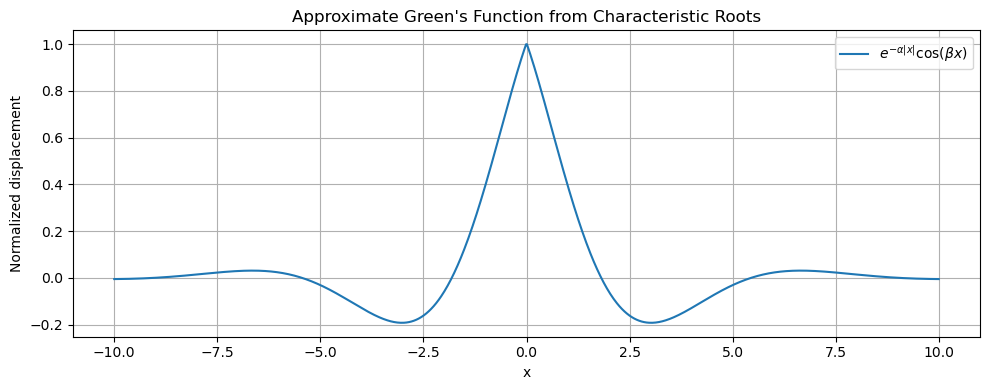

In [105]:
x = np.linspace(-10,10,1000)
# 알파, 베타 값
alpha = 1/2
beta = np.sqrt(3)/2

# Green's function 감쇠 진동 형태
G_approx = np.exp(-alpha * np.abs(x)) * np.cos(beta * x)

# 정규화
G_approx /= np.max(np.abs(G_approx))

# 그래프 출력
plt.figure(figsize=(10, 4))
plt.plot(x, G_approx, label=r"$e^{-\alpha |x|} \cos(\beta x)$")
plt.title("Approximate Green's Function from Characteristic Roots")
plt.xlabel("x")
plt.ylabel("Normalized displacement")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kk980\AppData\Local\Temp\ipykernel_122060\839750874.py:16: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Convolution: Green's Function with $\delta(x-a) - \delta(x+a)$")


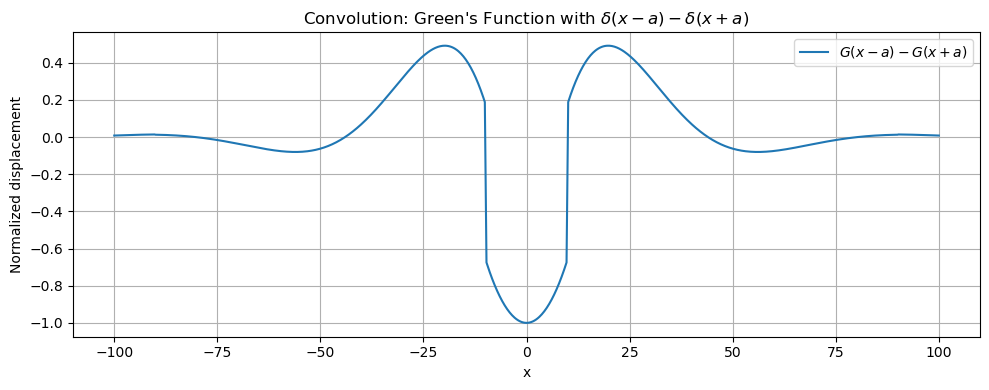

In [112]:
# 주어진 Green's function G(x)와 delta(x-a) - delta(x+a)의 컨볼루션
# delta(x-a) - delta(x+a)는 G(x-a) - G(x+a) 와 동일한 결과를 줌
x = np.linspace(-100,100,1000)
a = 10  # 위치 오프셋
G_conv = G_approx.copy()

# G(x-a) - G(x+a)
G_shifted = np.interp(x - a, x, G_approx, left=0, right=0) - np.interp(x - a + 0.1, x, G_approx, left=0, right=0) - np.interp(x + a - 0.1, x, G_approx, left=0, right=0) + np.interp(x + a, x, G_approx, left=0, right=0)

# 정규화
G_shifted /= np.max(np.abs(G_shifted))

# 그래프 출력
plt.figure(figsize=(10, 4))
plt.plot(x, G_shifted, label=r"$G(x-a) - G(x+a)$")
plt.title("Convolution: Green's Function with $\delta(x-a) - \delta(x+a)$")
plt.xlabel("x")
plt.ylabel("Normalized displacement")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [113]:
1/12 * 1e11 * (30e-6)**3

0.000225

In [115]:
1/3000

0.0003333333333333333

In [127]:


print(responses_cutoff[1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

C:\Users\kk980\AppData\Local\Temp\ipykernel_122060\4232925043.py:14: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, _ = quad(integrand, -np.inf, np.inf, limit=1000)
C:\Users\kk980\AppData\Local\Temp\ipykernel_122060\4232925043.py:14: IntegrationWarning: The maximum number of subdivisions (1000) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, -np.inf, np.inf, limit=1000)


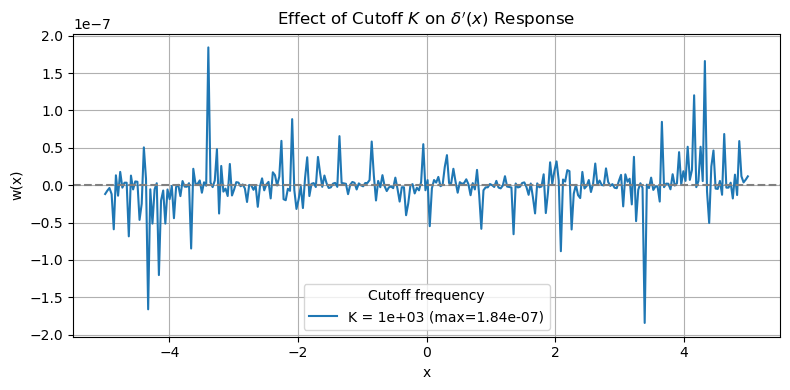

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- 응답 계산 함수 ---
def compute_green_delta_prime_response_cutoff(d4, d2, d1, x_array, K):
    # Fourier transform of Green's function: 1 / (k^4 + ik + 1)
    def G_hat(k):
        return 1j * k / (d4*k**4 + 1j * d2 * k**2 + d1)

    # Inverse Fourier transform: G(x) = (1/2π) ∫ e^{ikx} G_hat(k) dk
    def G_func(x_val):
        integrand = lambda k: np.real(np.exp(1j * k * x_val) * G_hat(k))
        result, _ = quad(integrand, -np.inf, np.inf, limit=500)
        return result / (2 * np.pi)

    return np.array([G_func(x) for x in x_array])


# --- 파라미터 설정 ---
d4, d2, d1 =1e-3,1e6,1e11#            # 방정식 계수
x_vals_zoom = np.linspace(-5, 5, 300)  # x 구간
cutoffs = [1e3]                 # cutoff k값

# --- 응답 계산 ---
responses_cutoff = [
    compute_green_delta_prime_response_cutoff(d4, d2, d1, x_vals_zoom, K)
    for K in cutoffs
]

# --- y축 자동 스케일 조정 ---
global_max = max(np.max(np.abs(r)) for r in responses_cutoff)
y_limit = 1.2 * global_max

# --- 그래프 ---
plt.figure(figsize=(8, 4))
for response, K in zip(responses_cutoff, cutoffs):
    max_val = np.max(np.abs(response))
    plt.plot(x_vals_zoom, response, label=f"K = {int(K):.0e} (max={max_val:.2e})")

plt.axhline(0, color='gray', linestyle='--')
plt.title(r"Effect of Cutoff $K$ on $\delta'(x)$ Response")
plt.xlabel("x")
plt.ylabel("w(x)")
plt.grid(True)
plt.legend(title="Cutoff frequency")
plt.tight_layout()
plt.show()


In [147]:
def item_filter(codes, index, items):
    return [code for code in codes if code.split('#')[index] in items]


codes = ['22123#VN830410#TTADD']

item_filter(codes, 0, ['22123'])
    

['22123#VN830410#TTADD']

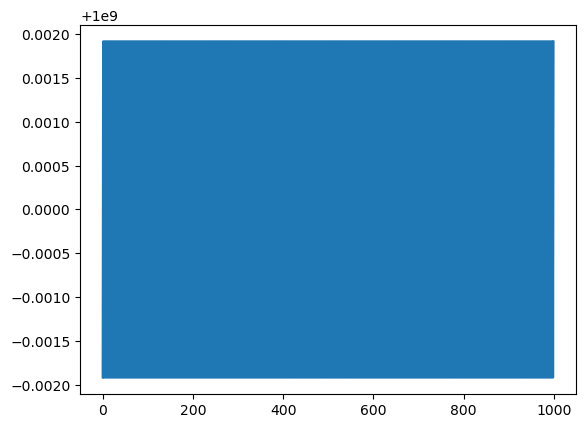

In [ ]:
msr_table = {'code1' : {'point1' : 'result1', 'point2' : 'result2', 'point3' : 'result3'}}
wf_table = ['code1','code2','code3'] #list of code

code = 'time'+'step'+'ppid'
